<a href="https://colab.research.google.com/github/aurora-nat/machine-vision-course/blob/main/labs/personal/Deep_Learning_practice.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Practice Deep Learning

Utilizing the Deep Learning with Python by Francois Chollet 2nd edition to practice



In [11]:
from tensorflow.keras.datasets import mnist

(train_images, train_labels), (test_images, test_labels) = mnist.load_data()
print(f"training images shape: ", train_images.shape)
print(f"tesitng images shape: ", test_images.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
training images shape:  (60000, 28, 28)
tesitng images shape:  (10000, 28, 28)


In [10]:
from tensorflow import keras
from tensorflow.keras import layers

#two Dense layers, output probability scores to identify the 10 digits
model = keras.Sequential([
    layers.Dense(512, activation="relu"),
    layers.Dense(10, activation="softmax")
])

In [11]:
model.compile(optimizer="rmsprop",
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])

In [12]:
#Prepare the image data: all values [0,1]
train_images = train_images.reshape((60000, 28 * 28))
train_images = train_images.astype("float32") / 255
test_images = test_images.reshape((10000, 28 * 28))
test_images = test_images.astype("float32") / 255

In [19]:
#flattened into 1D arrays
train_images.shape

(60000, 784)

In [13]:
#ready to train our model
model.fit(train_images, train_labels, epochs=5, batch_size=128)

Epoch 1/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.9251 - loss: 0.2609
Epoch 2/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.9692 - loss: 0.1063
Epoch 3/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.9790 - loss: 0.0705
Epoch 4/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.9852 - loss: 0.0508
Epoch 5/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.9887 - loss: 0.0383


In [14]:
#number of axes for our tensor:
train_images.ndim

2

In [15]:
#our dtype attribute
train_images.dtype

dtype('float32')

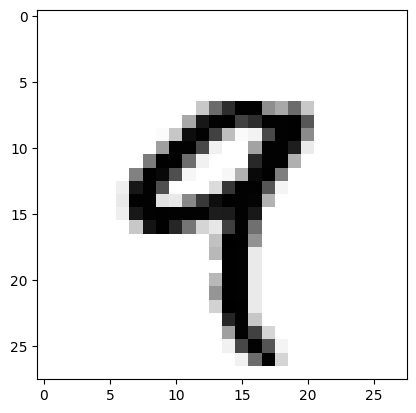

In [17]:
import matplotlib.pyplot as plt

# Get the fourth digit image
digit = train_images[4]

# Reshape the 1D digit array back to a 2D image (28x28 pixels)
digit_reshaped = digit.reshape(28, 28)

# Display the reshaped digit
plt.imshow(digit_reshaped, cmap=plt.cm.binary)
plt.show()

In [18]:
train_labels[4]

np.uint8(9)

# Create a naive sequential learning model

We will be creating a Dense layer and Sequential model by scratch in order to produce a deeper understanding on what Keras is doing behind the scenes.

In [18]:
import tensorflow as tf

class NaiveDense:
  def __init__(self, input_size, output_size, activation):
    self.activation = activation

    w_shape = (input_size, output_size)
    w_initial_value = tf.random.uniform(w_shape, minval=0, maxval=1e-1)
    self.W = tf.Variable(w_initial_value)

    b_shape = (output_size,)
    b_initial_value = tf.zeros(b_shape)
    self.b = tf.Variable(b_initial_value)

  def __call__(self, inputs):
    return self.activation(tf.matmul(inputs, self.W) + self.b)

  @property
  def weights(self):
    '''
    Convenient way to access the weights of a layer
    '''
    return [self.W, self.b]

In [2]:
class NaiveSequential:
    def __init__(self, layers):
        self.layers = layers

    def __call__(self, inputs):
        x = inputs
        for layer in self.layers:
            x = layer(x)
        return x

    @property
    def weights(self):
      weights = []
      for layers in self.layers:
        weights += layers.weights
      return weights

In [20]:
#Now we can create our model

model = NaiveSequential([
    NaiveDense(input_size=28 * 28, output_size=512, activation=tf.nn.relu),
    NaiveDense(input_size=512, output_size=10, activation=tf.nn.softmax)

])

assert len(model.weights) == 4

In [16]:
import math
#Create our batch generator, to create our batches
class BatchGenerator:
  def __init__(self, images, labels, batch_size=128):
    assert len(images) == len(labels)
    self.index=0
    self.images = images
    self.labels = labels
    self.batch_size = batch_size
    self.num_batches = math.ceil(len(images)/ batch_size)

  def next(self):
    images = self.images[self.index : self.index + self.batch_size]
    labels = self.labels[self.index : self.index + self.batch_size]
    self.index += self.batch_size
    return images, labels

In [49]:
# We specify a general learning rate, and we update the weights from our training_step
learning_rate = 1e-3

def update_weights(gradients, weights):
  for g, w in zip(gradients, weights):
    # w-= g * learning rate
    w.assign_sub(g * learning_rate)

In [50]:
def one_training_step(model, images_batch, labels_batch):
  #gradient tape captures important gradient information to make calculation more efficient
  with tf.GradientTape() as tape:
    predictions = model(images_batch)
    per_sample_losses = tf.keras.losses.sparse_categorical_crossentropy(
        labels_batch, predictions)
    average_loss = tf.reduce_mean(per_sample_losses)
  gradients = tape.gradient(average_loss, model.weights)
  update_weights(gradients, model.weights)
  return average_loss

In [8]:
from tensorflow.keras import optimizers

optimizers = optimizers.SGD(learning_rate=learning_rate)

def update_weights(gradients, weights):
  optimizers.apply_gradients(zip(gradients, weights))

In [9]:
def fit(model, images, labels, epochs, batch_size=128):
  for epoch_counter in range(epochs):
    print(f"Epoch {epoch_counter}")
    batch_generator = BatchGenerator(images, labels)
    for batch_counter in range(batch_generator.num_batches):
      images_batch, labels_batch = batch_generator.next()
      loss = one_training_step(model, images_batch, labels_batch)
      if batch_counter %100 == 0:
        print(f"loss at batch {batch_counter}: {loss:.2f}")

In [21]:
import numpy as np
fit(model, train_images, train_labels, epochs=10, batch_size=128)
predictions = model(test_images)
predictions = predictions.numpy()
predicted_labels = np.argmax(predictions, axis=1)
matches = predicted_labels == test_labels
print(f"accuracy: {matches.mean():.2f}")

Epoch 0
loss at batch 0: 3.73
loss at batch 100: 2.27
loss at batch 200: 2.27
loss at batch 300: 2.14
loss at batch 400: 2.28
Epoch 1
loss at batch 0: 1.94
loss at batch 100: 1.91
loss at batch 200: 1.90
loss at batch 300: 1.76
loss at batch 400: 1.89
Epoch 2
loss at batch 0: 1.61
loss at batch 100: 1.62
loss at batch 200: 1.58
loss at batch 300: 1.48
loss at batch 400: 1.56
Epoch 3
loss at batch 0: 1.35
loss at batch 100: 1.37
loss at batch 200: 1.30
loss at batch 300: 1.25
loss at batch 400: 1.31
Epoch 4
loss at batch 0: 1.14
loss at batch 100: 1.18
loss at batch 200: 1.09
loss at batch 300: 1.08
loss at batch 400: 1.13
Epoch 5
loss at batch 0: 0.99
loss at batch 100: 1.04
loss at batch 200: 0.93
loss at batch 300: 0.96
loss at batch 400: 1.00
Epoch 6
loss at batch 0: 0.87
loss at batch 100: 0.92
loss at batch 200: 0.82
loss at batch 300: 0.86
loss at batch 400: 0.91
Epoch 7
loss at batch 0: 0.79
loss at batch 100: 0.84
loss at batch 200: 0.74
loss at batch 300: 0.79
loss at batch 40

# Introduction to Keras

In [22]:
#Generating two classes of random points in a 2D plane
num_samples_per_class = 1000
negative_samples = np.random.multivariate_normal(
    mean=[0,3],
    cov = [[1,0.5], [0.5, 1]],
    size=num_samples_per_class
)
positive_samples = np.random.multivariate_normal(
    mean=[3,0],
    cov = [[1,0.5], [0.5, 1]],
    size=num_samples_per_class
)



In [24]:
inputs=np.vstack((negative_samples, positive_samples)).astype(np.float32)

print(inputs.shape)

(2000, 2)


In [26]:
targets = np.vstack((np.zeros((num_samples_per_class, 1), dtype="float32"),
                     np.ones((num_samples_per_class,1) , dtype="float32")))

print(targets.shape)

(2000, 1)


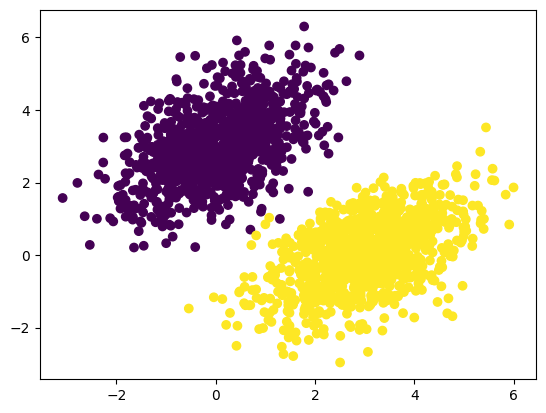

In [27]:
#plot the two point classes
import matplotlib.pyplot as plt
plt.scatter(inputs[:,0], inputs[:,1], c=targets[:,0])
plt.show()

In [30]:
#create a linear classifier

input_dim = 2
output_dim = 1

W = tf.Variable(initial_value=tf.random.uniform(shape=(input_dim, output_dim)))
b = tf.Variable(initial_value=tf.zeros(shape=(output_dim,)))

#forward pass function
def model(inputs):
  return tf.matmul(inputs, W) + b

#mean squared error loss function
def square_loss(targets, predictions):
  per_sample_losses = tf.square(targets - predictions)
  return tf.reduce_mean(per_sample_losses)

#training step

learning_rate = 0.1

def training_step(inputs, targets):
  with tf.GradientTape() as tape:
    predictions = model(inputs)
    loss= square_loss(targets, predictions)
  grad_loss_wrt_W, grad_loss_wrt_b = tape.gradient(loss, [W,b])
  W.assign_sub(grad_loss_wrt_W * learning_rate)
  b.assign_sub(grad_loss_wrt_b * learning_rate)
  return loss


 #batch training loop
for step in range(40):
  loss = training_step(inputs, targets)
  print(f"Loss at step {step}: {loss:.4f}")

Loss at step 0: 2.1600
Loss at step 1: 0.3747
Loss at step 2: 0.1504
Loss at step 3: 0.1147
Loss at step 4: 0.1039
Loss at step 5: 0.0968
Loss at step 6: 0.0906
Loss at step 7: 0.0850
Loss at step 8: 0.0799
Loss at step 9: 0.0752
Loss at step 10: 0.0709
Loss at step 11: 0.0670
Loss at step 12: 0.0633
Loss at step 13: 0.0600
Loss at step 14: 0.0570
Loss at step 15: 0.0542
Loss at step 16: 0.0517
Loss at step 17: 0.0494
Loss at step 18: 0.0472
Loss at step 19: 0.0453
Loss at step 20: 0.0435
Loss at step 21: 0.0418
Loss at step 22: 0.0403
Loss at step 23: 0.0389
Loss at step 24: 0.0377
Loss at step 25: 0.0365
Loss at step 26: 0.0355
Loss at step 27: 0.0345
Loss at step 28: 0.0336
Loss at step 29: 0.0328
Loss at step 30: 0.0320
Loss at step 31: 0.0314
Loss at step 32: 0.0307
Loss at step 33: 0.0302
Loss at step 34: 0.0296
Loss at step 35: 0.0291
Loss at step 36: 0.0287
Loss at step 37: 0.0283
Loss at step 38: 0.0279
Loss at step 39: 0.0276


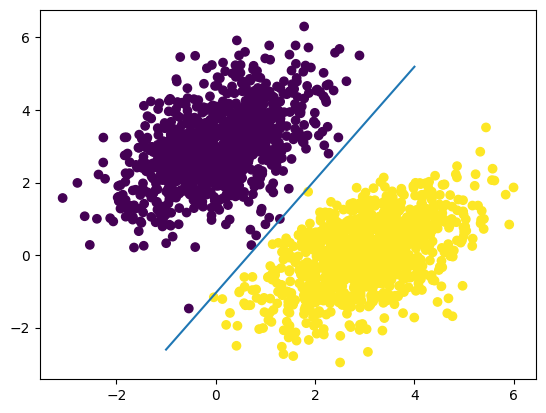

In [29]:
x = np.linspace(-1, 4, 100)
y = -W[0] / W[1] * x + (0.5 - b) / W[1]
plt.plot(x,y)
plt.scatter(inputs[:,0], inputs[:,1], c=predictions[:,0] > 0.5)
plt.show()

# Binary Classification Examples

We are working with the IMDB dataset, of 50,000 highly polarized reviews from the Internet Movie Database. We are keeping the top 10,0000 most frequently occuring words in the training data. Each training example has a list of word indices (encoding a sequence of words), and the training labels have a 0 or 1 indicating a negative or positive review, respectively.

In [31]:
#Load the IMDB dataset
from tensorflow.keras.datasets import imdb
(train_data, train_lables), (test_data, test_labels) = imdb.load_data(num_words=10000)

print(f"Training data example: {train_data[0]}")
print(f"Training data label example: {train_lables[0]}")

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training data example: [1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65, 458, 4468, 66, 3941, 4, 173, 36, 256, 5, 25, 100, 43, 838, 112, 50, 670, 2, 9, 35, 480, 284, 5, 150, 4, 172, 112, 167, 2, 336, 385, 39, 4, 172, 4536, 1111, 17, 546, 38, 13, 447, 4, 192, 50, 16, 6, 147, 2025, 19, 14, 22, 4, 1920, 4613, 469, 4, 22, 71, 87, 12, 16, 43, 530, 38, 76, 15, 13, 1247, 4, 22, 17, 515, 17, 12, 16, 626, 18, 2, 5, 62, 386, 12, 8, 316, 8, 106, 5, 4, 2223, 5244, 16, 480, 66, 3785, 33, 4, 130, 12, 16, 38, 619, 5, 25, 124, 51, 36, 135, 48, 25, 1415, 33, 6, 22, 12, 215, 28, 77, 52, 5, 14, 407, 16, 82, 2, 8, 4, 107, 117, 5952, 15, 256, 4, 2, 7, 3766, 5, 723, 36, 71, 43, 530, 476, 26, 400, 317, 46, 7, 4, 2, 1029, 13, 104, 88, 4, 381, 15, 297, 98, 32, 2071, 56, 26, 141, 6, 194, 7486, 18, 4, 226, 22, 21, 134, 476, 26, 480, 5, 144, 30, 5535, 18, 51, 36, 28, 224, 92, 25, 104, 4, 226, 65, 16, 38, 1334, 88, 12, 16, 283, 5, 16, 4472, 113, 103, 32, 15, 16, 5345,

In [36]:
#word_index is a dictionary  mapping words to an integer index
word_index = imdb.get_word_index()

#maps integer indices to the words
reverse_word_index = dict(
    [ (value, key) for (key, value) in word_index.items()])

decoded_review = " ".join(
    [reverse_word_index.get(i-3, "?") for i in train_data[0]]
)

print(f"Decoded Review Example: {decoded_review}")

Decoded Review Example: ? this film was just brilliant casting location scenery story direction everyone's really suited the part they played and you could just imagine being there robert ? is an amazing actor and now the same being director ? father came from the same scottish island as myself so i loved the fact there was a real connection with this film the witty remarks throughout the film were great it was just brilliant so much that i bought the film as soon as it was released for ? and would recommend it to everyone to watch and the fly fishing was amazing really cried at the end it was so sad and you know what they say if you cry at a film it must have been good and this definitely was also ? to the two little boy's that played the ? of norman and paul they were just brilliant children are often left out of the ? list i think because the stars that play them all grown up are such a big profile for the whole film but these children are amazing and should be praised for what they

In [38]:
#Encoding the integer sequences via multi-hot encoding
import numpy as np

def vectorize_sequences(sequences, dimension=10000):
  results = np.zeros((len(sequences), dimension))
  for i, sequence in enumerate(sequences):
    for j in sequence:
      results[i, j] = 1.
  return results

x_train = vectorize_sequences(train_data)
x_test = vectorize_sequences(test_data)

print(f"Example of what samples look like now: {x_train[0]}")

Example of what samples look like now: [0. 1. 1. ... 0. 0. 0.]


In [39]:
y_train = np.array(train_lables).astype("float32")
y_test = np.array(test_labels).astype("float32")

In [40]:
#Now data is ready to be fed into our model
from tensorflow import keras
from tensorflow.keras import layers

model = keras.Sequential([
    layers.Dense(16, activation="relu"),
    layers.Dense(16, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])

model.compile(optimizer = "rmsprop",
              loss = "binary_crossentropy",
              metrics =["accuracy"])

x_val = x_train[:10000]
partial_x_train = x_train[10000:]

y_val = y_train[:10000]
partial_y_train = y_train[10000:]

history = model.fit(partial_x_train,
                    partial_y_train,
                    epochs=20,
                    batch_size=512,
                    validation_data=(x_val, y_val))

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 62ms/step - accuracy: 0.7713 - loss: 0.5493 - val_accuracy: 0.8646 - val_loss: 0.4195
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.8887 - loss: 0.3438 - val_accuracy: 0.8833 - val_loss: 0.3211
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.9135 - loss: 0.2555 - val_accuracy: 0.8834 - val_loss: 0.2925
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step - accuracy: 0.9298 - loss: 0.2070 - val_accuracy: 0.8907 - val_loss: 0.2738
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step - accuracy: 0.9455 - loss: 0.1690 - val_accuracy: 0.8884 - val_loss: 0.2777
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.9499 - loss: 0.1481 - val_accuracy: 0.8862 - val_loss: 0.2871
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.9623 - loss: 0.1224 - val_accuracy: 0.8851 - val_loss: 0.2958
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.9659 - loss: 0.1083 - val_accuracy: 0.8833 - v

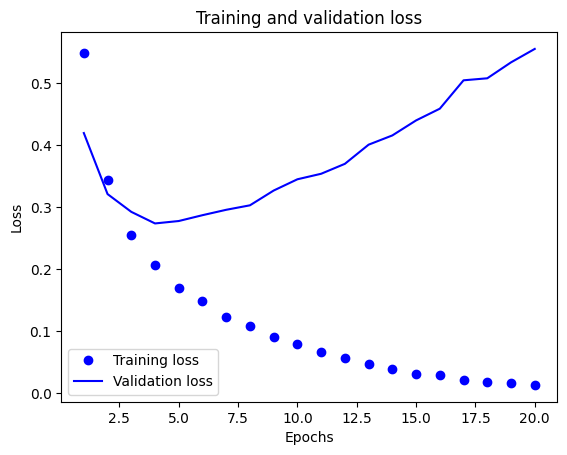

In [41]:
#Plot our training and validation losses:
import matplotlib.pyplot as plt
history_dict = history.history
loss_values = history_dict["loss"]
val_loss_values = history_dict["val_loss"]
epochs = range(1, len(loss_values) +1)
plt.plot(epochs, loss_values, "bo", label="Training loss")
plt.plot(epochs, val_loss_values, "b", label="Validation loss")
plt.title("Training and validation loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

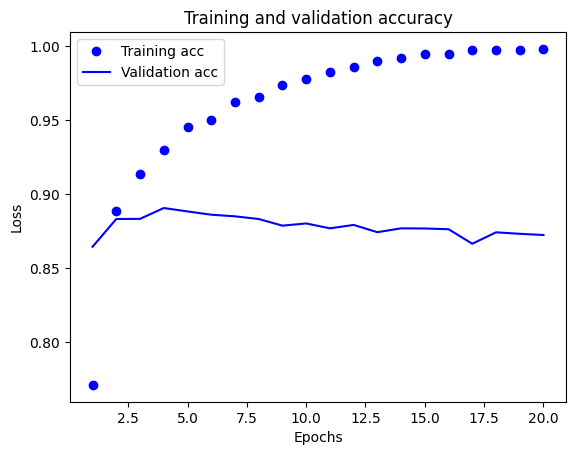

In [42]:
#plotting the training and validation accuracy
plt.clf()
acc = history_dict["accuracy"]
val_acc = history_dict["val_accuracy"]
plt.plot(epochs, acc, "bo", label="Training acc")
plt.plot(epochs, val_acc, "b", label="Validation acc")
plt.title("Training and validation accuracy")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()


We can see that the training starts to deviate from the validation loss around epoch four, and we are dealing with overfitting, so that we are overoptimizing on the training data and not generalizing well. We can always specify our model to only train up until the epoch 4 where we saw the overfitting occuring:

In [43]:
model= keras.Sequential([
    layers.Dense(16, activation="relu"),
    layers.Dense(16, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])
model.compile(optimizer="rmsprop",
              loss="binary_crossentropy",
              metrics=["accuracy"])
model.fit(x_train, y_train, epochs=4, batch_size=512)
results = model.evaluate(x_test, y_test)
print(f"Our results: {results}")

model.predict(x_test)

Epoch 1/4
49/49 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - accuracy: 0.8053 - loss: 0.4936
Epoch 2/4
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - accuracy: 0.8977 - loss: 0.2914
Epoch 3/4
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.9166 - loss: 0.2281
Epoch 4/4
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.9298 - loss: 0.1908
782/782 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8880 - loss: 0.2797
Our results: [0.279701828956604, 0.8879600167274475]
782/782 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step


array([[0.21221794],
       [0.99985313],
       [0.81526244],
       ...,
       [0.09573805],
       [0.07990903],
       [0.5707223 ]], dtype=float32)

# Multi-class classification example

### Classifying newswires

We will be working with the Reuters dataset, a set of short newswires and their topics, published by Reuters in 1986. It is a widely used toy dataset for text classification. There are 46 different topics; some topics are more represented than others, but each topic has at least 10 examples in the training set.

In [45]:
from tensorflow.keras.datasets  import reuters
(train_data, train_labels), (test_data, test_labels) = reuters.load_data(num_words=10000)

print(f"Length of training data: {len(train_data)}")
print(f"Length of testing data: {len(test_data)}")

word_index = reuters.get_word_index()
reverse_word_index = dict([(value, key) for (key, value) in word_index.items()])
decoded_newswire = " ".join(
    [reverse_word_index.get(i-3, "?") for i in train_data[0]]
)
print(f"Decoded Newswires Example: {decoded_newswire}")
print(f"Label Example: {train_labels[0]}")

Length of training data: 8982
Length of testing data: 2246
Decoded Newswires Example: ? ? ? said as a result of its december acquisition of space co it expects earnings per share in 1987 of 1 15 to 1 30 dlrs per share up from 70 cts in 1986 the company said pretax net should rise to nine to 10 mln dlrs from six mln dlrs in 1986 and rental operation revenues to 19 to 22 mln dlrs from 12 5 mln dlrs it said cash flow per share this year should be 2 50 to three dlrs reuter 3
Label Example: 3


In [47]:
from tensorflow.keras.utils import to_categorical
#vectorize the input data
x_train = vectorize_sequences(train_data)
x_test = vectorize_sequences(test_data)

#one-hot encode labels to 46 categories automatical with Keras API to_categorical
y_train = to_categorical(train_labels)
y_test = to_categorical(test_labels)

model = keras.Sequential([
    layers.Dense(64, activation="relu"),
    layers.Dense(64, activation="relu"),
    layers.Dense(46, activation="softmax")
])

model.compile(optimizer="rmsprop",
              loss="categorical_crossentropy",
              metrics=["accuracy"])

x_val = x_train[:1000]
partial_x_train = x_train[1000:]

y_val = y_train[:1000]
partial_y_train = y_train[1000:]

history = model.fit(partial_x_train,
                    partial_y_train,
                    epochs=20,
                    batch_size=512,
                    validation_data=(x_val, y_val))


Epoch 1/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 4s 162ms/step - accuracy: 0.5049 - loss: 2.7421 - val_accuracy: 0.6170 - val_loss: 1.8525
Epoch 2/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 119ms/step - accuracy: 0.6718 - loss: 1.5629 - val_accuracy: 0.6880 - val_loss: 1.4005
Epoch 3/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 84ms/step - accuracy: 0.7334 - loss: 1.2073 - val_accuracy: 0.7220 - val_loss: 1.2125
Epoch 4/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 90ms/step - accuracy: 0.7851 - loss: 0.9963 - val_accuracy: 0.7500 - val_loss: 1.1131
Epoch 5/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 65ms/step - accuracy: 0.8210 - loss: 0.8338 - val_accuracy: 0.7800 - val_loss: 1.0211
Epoch 6/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - accuracy: 0.8503 - loss: 0.6972 - val_accuracy: 0.7780 - val_loss: 0.9842
Epoch 7/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - accuracy: 0.8700 - loss: 0.5861 - val_accuracy: 0.8070 - val_loss: 0.9173
Epoch 8/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 66ms/step - accuracy: 0.8931 - loss: 0.4953 - val_accuracy: 0.8170 -

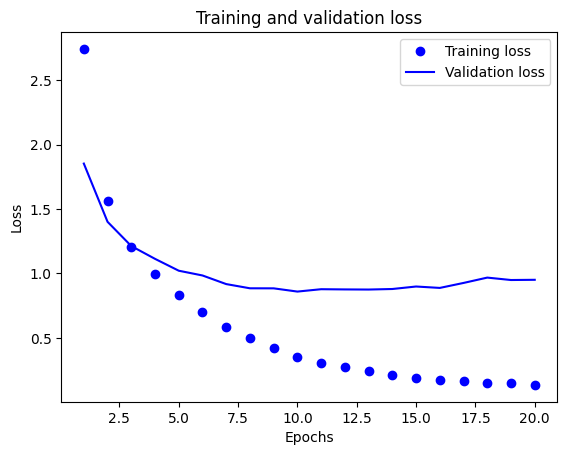

In [48]:
loss = history.history["loss"]
val_loss = history.history["val_loss"]
epochs = range(1, len(loss) + 1)
plt.plot(epochs, loss, "bo", label="Training loss")
plt.plot(epochs, val_loss, "b", label="Validation loss")
plt.title("Training and validation loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

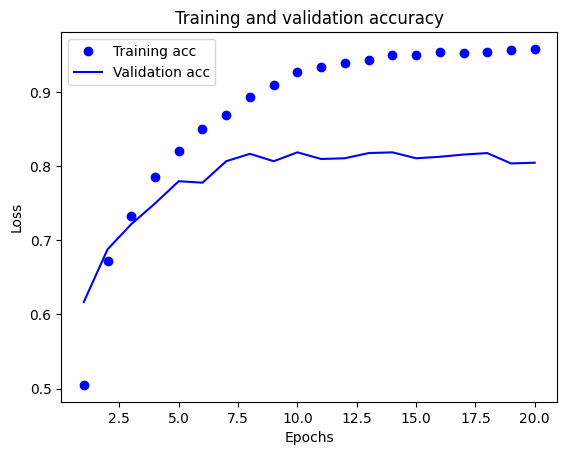

In [51]:
#plotting training and validation accuracy
plt.clf()
acc = history.history["accuracy"]
val_acc = history.history["val_accuracy"]
plt.plot(epochs, acc, "bo", label="Training acc")
plt.plot(epochs, val_acc, "b", label="Validation acc")
plt.title("Training and validation accuracy")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()